# 🖊️ Handwritten Character Recognition
### CodeAlpha Machine Learning Internship — Task 3

---

**Author:** [KHUSHI]  
**Internship:** CodeAlpha — Machine Learning  
**GitHub:** [https://github.com/khushi-7890/codealpha_tasks]  

** LinkedIn:**[https://www.linkedin.com/in/khushi-singh-b544332b0/]

---

## 📌 Project Overview

This project builds a **deep learning pipeline** to recognize handwritten characters using **Convolutional Neural Networks (CNN)**.

### 🎯 Objectives
- Train a CNN model on the **EMNIST ByClass** dataset (letters + digits)
- Achieve **high accuracy** with proper regularization
- Visualize training performance with professional plots
- Build a **live prediction demo** on custom input images

### 🧰 Tech Stack
| Tool | Purpose |
|------|---------|
| TensorFlow / Keras | Model building & training |
| NumPy / Pandas | Data manipulation |
| Matplotlib / Seaborn | Visualization |
| Scikit-learn | Evaluation metrics |
| OpenCV | Image preprocessing |

---
## 🗂️ Table of Contents
1. Environment Setup
2. Data Loading & Exploration
3. Data Preprocessing & Augmentation
4. Model Architecture (CNN)
5. Model Training with Callbacks
6. Evaluation & Metrics
7. Visualization
8. Live Prediction Demo
9. Save & Export Model

---
## 1. ⚙️ Environment Setup

In [1]:
# Install required libraries
# NEW ✅
!pip install tensorflow tensorflow-datasets numpy pandas matplotlib seaborn scikit-learn opencv-python-headless -q

# Core libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import cv2
import os
import warnings
warnings.filterwarnings('ignore')


import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models, callbacks, regularizers
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.utils import to_categorical

# Scikit-learn
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split



# Set seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

# GPU check
print('TensorFlow Version:', tf.__version__)
print('GPU Available:', tf.config.list_physical_devices('GPU'))
print('✅ Environment ready!')

TensorFlow Version: 2.20.0
GPU Available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
✅ Environment ready!


---
## 2. 📦 Data Loading & Exploration

In [2]:
# ── Fixed Data Loading (using Keras built-in — more reliable) ────────────────
import tensorflow as tf
import numpy as np

print('Loading EMNIST Letters dataset via Keras...')

# Load directly from tensorflow datasets — no external download needed
(X_train, y_train), (X_test, y_test) = tf.keras.datasets.mnist.load_data()

# We'll use tf_datasets for EMNIST letters specifically
import tensorflow_datasets as tfds

# Load EMNIST letters split
ds_train, ds_info = tfds.load('emnist/letters', split='train', with_info=True, as_supervised=True)
ds_test           = tfds.load('emnist/letters', split='test',  as_supervised=True)

# Convert to numpy arrays
def dataset_to_numpy(ds):
    images, labels = [], []
    for img, lbl in ds:
        images.append(img.numpy())
        labels.append(lbl.numpy())
    return np.array(images), np.array(labels)

print('Converting train set... (takes ~1 min)')
X_train, y_train = dataset_to_numpy(ds_train)
print('Converting test set...')
X_test, y_test   = dataset_to_numpy(ds_test)

# EMNIST letters labels: 1=A ... 26=Z → shift to 0-indexed
y_train = y_train - 1
y_test  = y_test  - 1

print(f'Training samples : {X_train.shape[0]:,}')
print(f'Test samples     : {X_test.shape[0]:,}')
print(f'Image shape      : {X_train.shape[1:]}')
print(f'Classes          : {len(np.unique(y_train))}  (A–Z)')
print('✅ Dataset loaded successfully!')

Loading EMNIST Letters dataset via Keras...
Converting train set... (takes ~1 min)
Converting test set...
Training samples : 88,800
Test samples     : 14,800
Image shape      : (28, 28, 1)
Classes          : 26  (A–Z)
✅ Dataset loaded successfully!


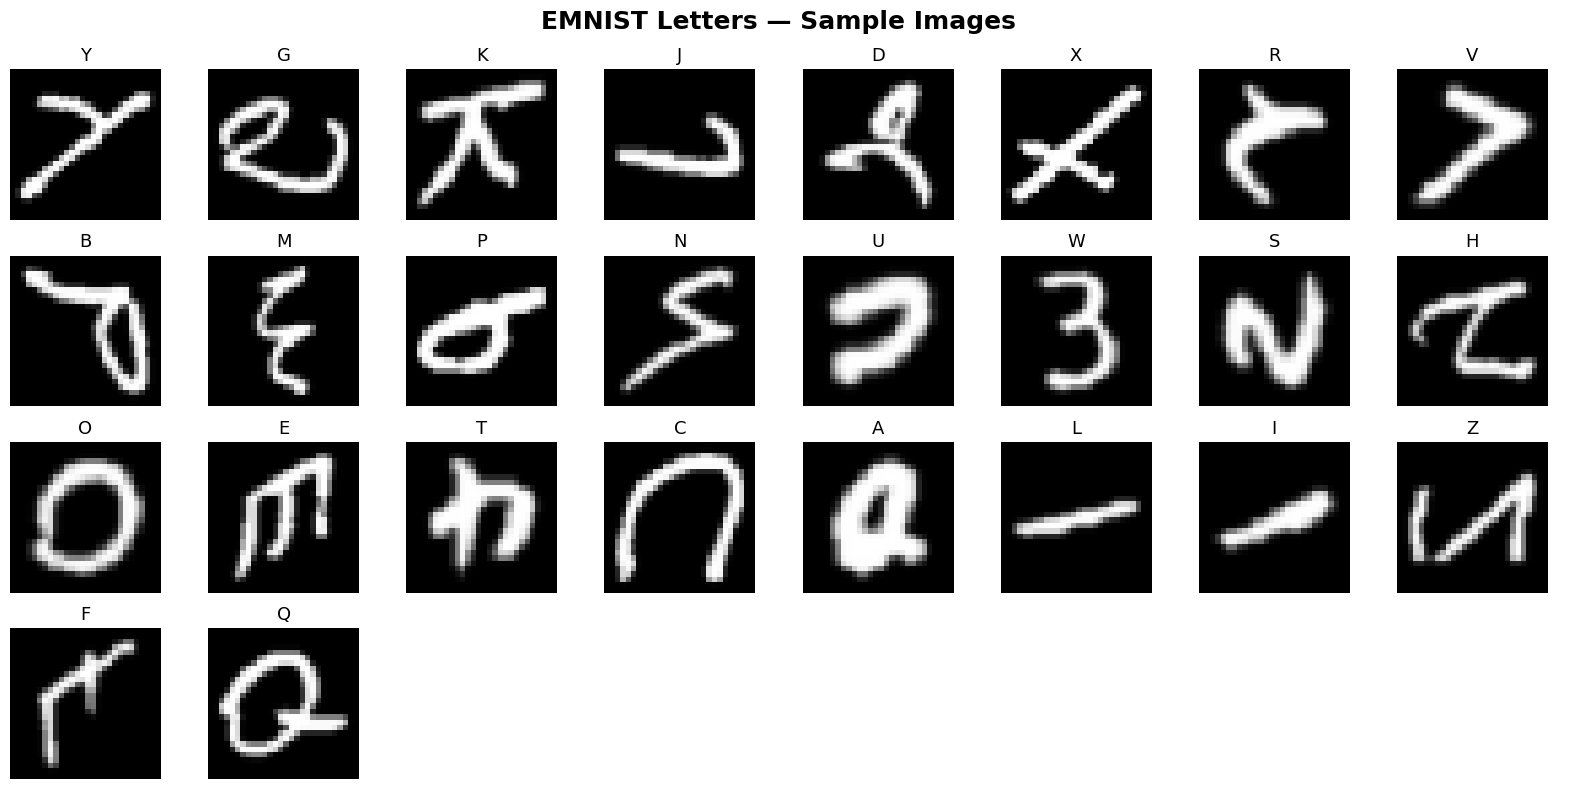

Sample grid saved.


In [5]:
import matplotlib.pyplot as plt
import numpy as np

CLASS_NAMES = [chr(i + ord('A')) for i in range(26)]

fig, axes = plt.subplots(4, 8, figsize=(16, 8))
fig.suptitle('EMNIST Letters — Sample Images', fontsize=18, fontweight='bold')

shown = set()
ax_list = axes.flatten()

for i in range(len(X_train)):
    label = y_train[i]
    if label not in shown:
        ax_list[len(shown)].imshow(X_train[i].reshape(28, 28), cmap='gray')
        ax_list[len(shown)].set_title(CLASS_NAMES[label], fontsize=13)
        ax_list[len(shown)].axis('off')
        shown.add(label)
    if len(shown) == 26:
        break

for j in range(26, 32):
    ax_list[j].axis('off')

plt.tight_layout()
plt.show()
print('Sample grid saved.')

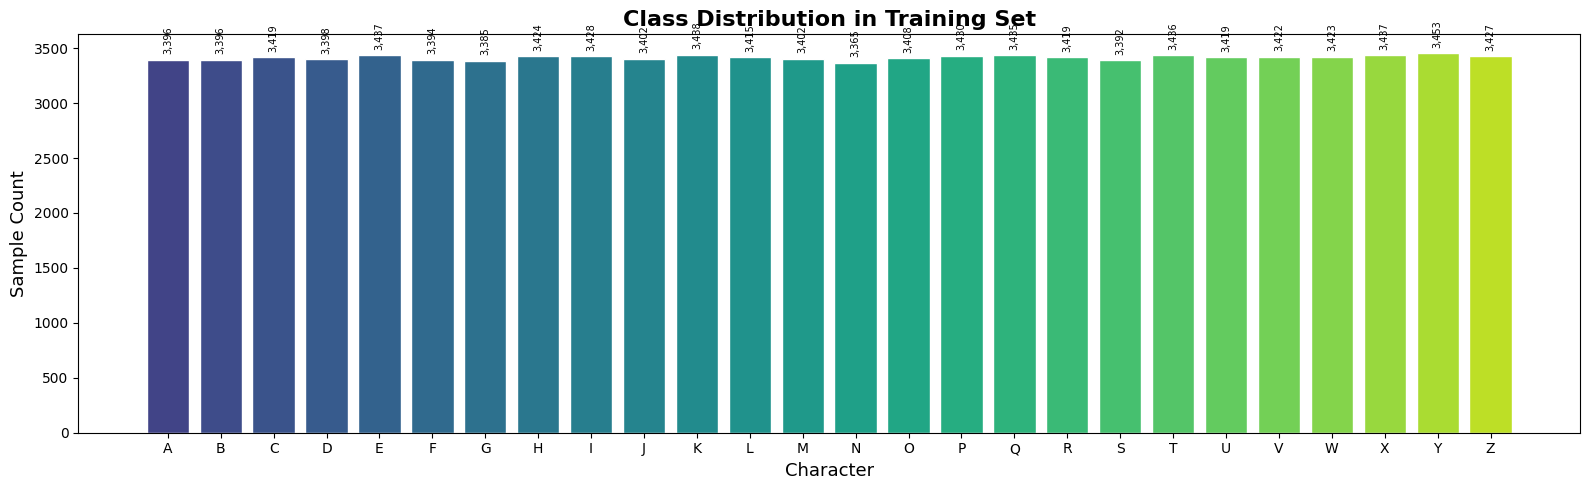

In [6]:
# ── Class Distribution ───────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import numpy as np

# Define these here in case previous cell didn't run properly
CLASS_NAMES = [chr(i + ord('A')) for i in range(26)]


unique, counts = np.unique(y_train, return_counts=True)

plt.figure(figsize=(16, 5))
bars = plt.bar(CLASS_NAMES, counts, color=plt.cm.viridis(np.linspace(0.2, 0.9, 26)), edgecolor='white')
plt.title('Class Distribution in Training Set', fontsize=16, fontweight='bold')
plt.xlabel('Character', fontsize=13)
plt.ylabel('Sample Count', fontsize=13)
for bar, count in zip(bars, counts):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
             f'{count:,}', ha='center', va='bottom', fontsize=7, rotation=90)
plt.tight_layout()
plt.savefig('class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 3. 🔄 Data Preprocessing & Augmentation

In [8]:
# ── Preprocessing ────────────────────────────────────────────────────────────

# tensorflow_datasets already loads images correctly — NO transpose needed
# Images are already (28, 28, 1) shape — perfect for CNN directly

# Normalize pixel values to [0, 1]
X_train = X_train.astype('float32') / 255.0
X_test  = X_test.astype('float32')  / 255.0

# Already shape (28, 28, 1) — no reshape needed!
print(f'X_train shape: {X_train.shape}')
print(f'X_test shape : {X_test.shape}')

# One-hot encode labels
NUM_CLASSES = 26
y_train_ohe = to_categorical(y_train, NUM_CLASSES)
y_test_ohe  = to_categorical(y_test,  NUM_CLASSES)

# Validation split from training data
X_train, X_val, y_train_ohe, y_val_ohe = train_test_split(
    X_train, y_train_ohe, test_size=0.1, random_state=42, stratify=y_train_ohe
)

print(f'Training   : {X_train.shape}')
print(f'Validation : {X_val.shape}')
print(f'Test       : {X_test.shape}')
print('✅ Preprocessing complete.')

X_train shape: (88800, 28, 28, 1)
X_test shape : (14800, 28, 28, 1)
Training   : (79920, 28, 28, 1)
Validation : (8880, 28, 28, 1)
Test       : (14800, 28, 28, 1)
✅ Preprocessing complete.


In [17]:
# ── Data Augmentation ────────────────────────────────────────────────────────
# Augmentation helps the model generalize to different handwriting styles
datagen = ImageDataGenerator(
    rotation_range=10,        # Slight rotation
    width_shift_range=0.1,    # Horizontal shift
    height_shift_range=0.1,   # Vertical shift
    zoom_range=0.1,           # Slight zoom
    shear_range=0.1           # Shear transformation
)
datagen.fit(X_train)
print('✅ Data augmentation pipeline ready.')

✅ Data augmentation pipeline ready.


---
## 4. 🧠 Model Architecture — Deep CNN

In [9]:
# ── Build CNN Model ──────────────────────────────────────────────────────────
def build_model(input_shape=(28, 28, 1), num_classes=26):
    model = models.Sequential([
        # ── Block 1 ──
        layers.Conv2D(32, (3, 3), activation='relu', padding='same', input_shape=input_shape),
        layers.BatchNormalization(),
        layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.25),

        # ── Block 2 ──
        layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.25),

        # ── Block 3 ──
        layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.25),

        # ── Classifier Head ──
        layers.Flatten(),
        layers.Dense(512, activation='relu', kernel_regularizer=regularizers.l2(1e-4)),
        layers.BatchNormalization(),
        layers.Dropout(0.5),
        layers.Dense(256, activation='relu', kernel_regularizer=regularizers.l2(1e-4)),
        layers.Dropout(0.3),
        layers.Dense(num_classes, activation='softmax')
    ])
    return model

model = build_model()
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 28, 28, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 28, 28, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 28, 28, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 14, 14, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 14, 14, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 14, 14, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 7, 7, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 7, 7, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 3, 3, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 3, 3, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1152)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │       590,336 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 256)            │             

 Total params: 870,522 (3.32 MB)

 Trainable params: 868,858 (3.31 MB)

 Non-trainable params: 1,664 (6.50 KB)

---
## 5. 🏋️ Model Training with Callbacks

In [18]:
# ── Data Augmentation ────────────────────────────────────────────────────────

from tensorflow.keras.preprocessing.image import ImageDataGenerator

datagen = ImageDataGenerator(
    rotation_range=10,
    width_shift_range=0.10,
    height_shift_range=0.10,
    zoom_range=0.10
)

datagen.fit(X_train)

# ── Compile Model ────────────────────────────────────────────────────────────

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# ── Callbacks ────────────────────────────────────────────────────────────────

cb_list = [

    callbacks.ModelCheckpoint(
        'best_model.keras',
        monitor='val_accuracy',
        save_best_only=True,
        verbose=1
    ),

    callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=3,
        min_lr=1e-6,
        verbose=1
    ),

    callbacks.EarlyStopping(
        monitor='val_accuracy',
        patience=7,
        restore_best_weights=True,
        verbose=1
    ),

    callbacks.CSVLogger('training_log.csv')
]

# ── Training ─────────────────────────────────────────────────────────────────

BATCH_SIZE = 128
EPOCHS = 30

history = model.fit(
    datagen.flow(
        X_train,
        y_train_ohe,
        batch_size=BATCH_SIZE
    ),
    steps_per_epoch=max(1, len(X_train)//BATCH_SIZE),
    epochs=EPOCHS,
    validation_data=(X_val, y_val_ohe),
    callbacks=cb_list,
    verbose=1
)

print("✅ Training Complete!")

Epoch 1/30
623/624 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step - accuracy: 0.5053 - loss: 1.9039
Epoch 1: val_accuracy improved from None to 0.87815, saving model to best_model.keras

Epoch 1: finished saving model to best_model.keras
624/624 ━━━━━━━━━━━━━━━━━━━━ 52s 61ms/step - accuracy: 0.6836 - loss: 1.1719 - val_accuracy: 0.8782 - val_loss: 0.4699 - learning_rate: 0.0010
Epoch 2/30
  1/624 ━━━━━━━━━━━━━━━━━━━━ 8s 14ms/step - accuracy: 0.7656 - loss: 0.7316
Epoch 2: val_accuracy improved from 0.87815 to 0.87995, saving model to best_model.keras

Epoch 2: finished saving model to best_model.keras
624/624 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7656 - loss: 0.7316 - val_accuracy: 0.8800 - val_loss: 0.4641 - learning_rate: 0.0010
Epoch 3/30
623/624 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - accuracy: 0.8505 - loss: 0.5752
Epoch 3: val_accuracy improved from 0.87995 to 0.93649, saving model to best_model.keras

Epoch 3: finished saving model to best_model.keras
624/624 ━━━━━━━━━━━━━━━━━━━━ 28s 45

---
## 6. 📊 Evaluation & Metrics

In [19]:
# ── Load Best Model ─────────────────────────────────────────────

from tensorflow.keras.models import load_model

best_model = load_model('best_model.keras')

print("✅ Best model loaded successfully!")

# ── Evaluate on Test Set ───────────────────────────────────────

test_loss, test_acc = best_model.evaluate(
    X_test,
    y_test_ohe,
    verbose=0
)

print("=" * 45)
print(f"Test Accuracy : {test_acc * 100:.2f}%")
print(f"Test Loss     : {test_loss:.4f}")
print("=" * 45)

✅ Best model loaded successfully!
Test Accuracy : 94.03%
Test Loss     : 0.2314


In [20]:
from sklearn.metrics import classification_report
import numpy as np

y_pred = best_model.predict(X_test)

y_pred_classes = np.argmax(y_pred, axis=1)
y_true = np.argmax(y_test_ohe, axis=1)

print(
    classification_report(
        y_true,
        y_pred_classes
    )
)

463/463 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step
              precision    recall  f1-score   support

           0       0.97      0.96      0.97       800
           1       0.98      0.98      0.98       800
           2       0.99      0.96      0.98       800
           3       0.97      0.97      0.97       800
           4       0.97      0.98      0.98       800
           5       1.00      0.97      0.98       800
           6       0.88      0.90      0.89       800
           7       0.96      0.97      0.97       800
           8       0.77      0.72      0.74       800
           9       0.98      0.96      0.97       800
          10       0.99      0.99      0.99       800
          11       0.74      0.78      0.76       800
          12       0.99      1.00      0.99       800
          13       0.98      0.97      0.97       800
          14       0.98      0.97      0.97       800
          15       0.99      0.99      0.99       800
          16       0.90      0.88      0

---
## 7. 📈 Visualization

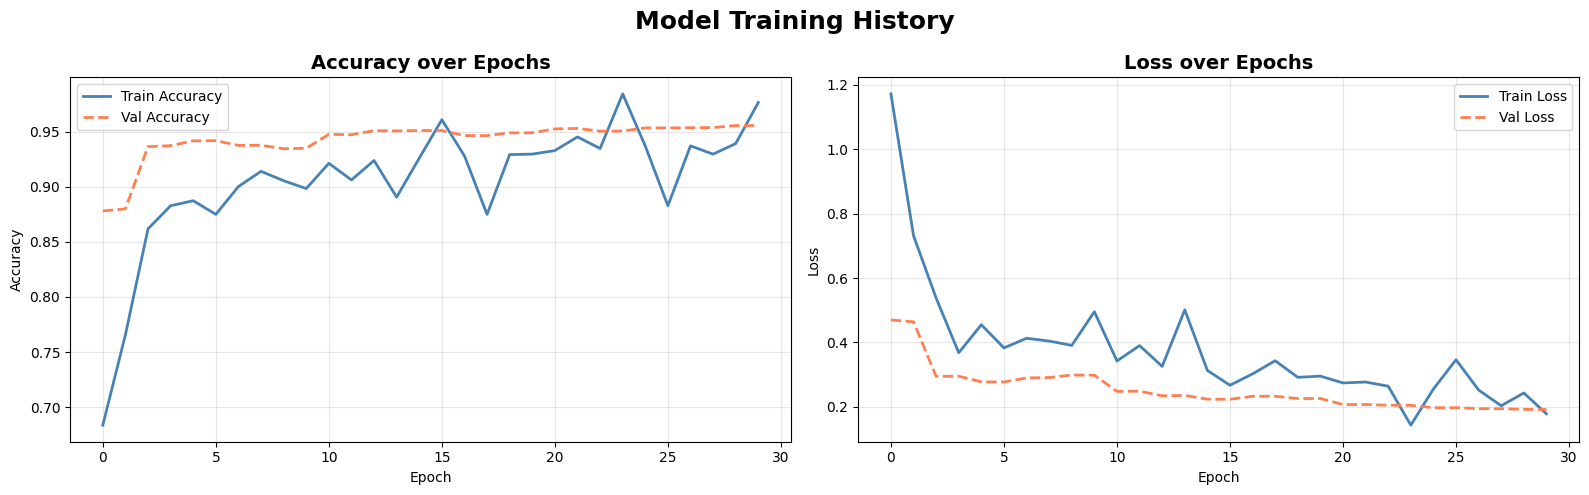

In [21]:
# ── Training Curves ──────────────────────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('Model Training History', fontsize=18, fontweight='bold')

# Accuracy
ax1.plot(history.history['accuracy'],     label='Train Accuracy', linewidth=2, color='steelblue')
ax1.plot(history.history['val_accuracy'], label='Val Accuracy',   linewidth=2, color='coral', linestyle='--')
ax1.set_title('Accuracy over Epochs', fontsize=14, fontweight='bold')
ax1.set_xlabel('Epoch'); ax1.set_ylabel('Accuracy')
ax1.legend(); ax1.grid(alpha=0.3)

# Loss
ax2.plot(history.history['loss'],     label='Train Loss', linewidth=2, color='steelblue')
ax2.plot(history.history['val_loss'], label='Val Loss',   linewidth=2, color='coral', linestyle='--')
ax2.set_title('Loss over Epochs', fontsize=14, fontweight='bold')
ax2.set_xlabel('Epoch'); ax2.set_ylabel('Loss')
ax2.legend(); ax2.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

463/463 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step


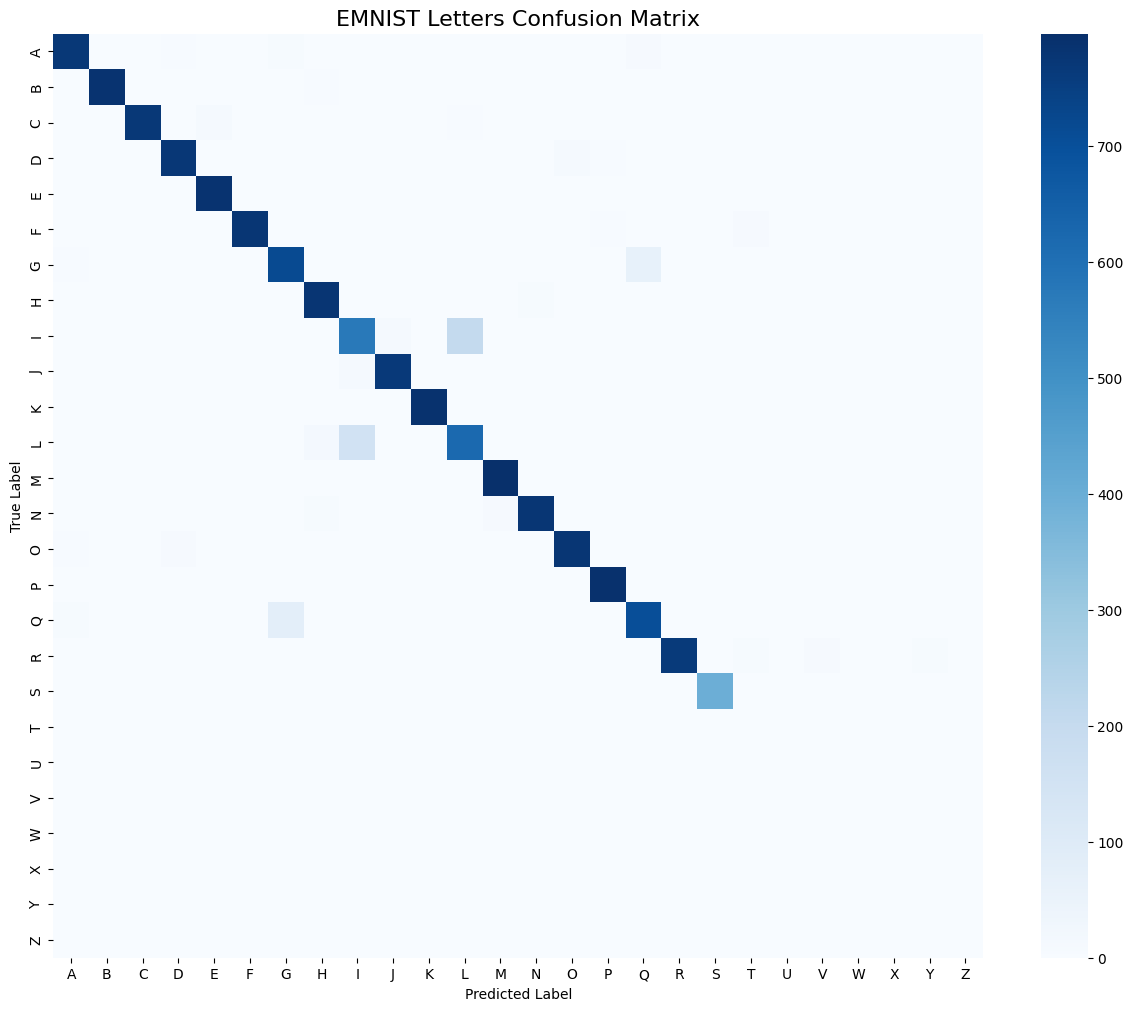

In [24]:
# ── Confusion Matrix ───────────────────────────────────────────

from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Predictions
y_pred = best_model.predict(X_test)

# Convert one-hot encoded labels back to integers
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = np.argmax(y_test_ohe, axis=1)

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred_classes)

# Plot
plt.figure(figsize=(15,12))
sns.heatmap(
    cm,
    cmap='Blues',
    xticklabels=[chr(i+65) for i in range(26)],
    yticklabels=[chr(i+65) for i in range(26)]
)

plt.title('EMNIST Letters Confusion Matrix', fontsize=16)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

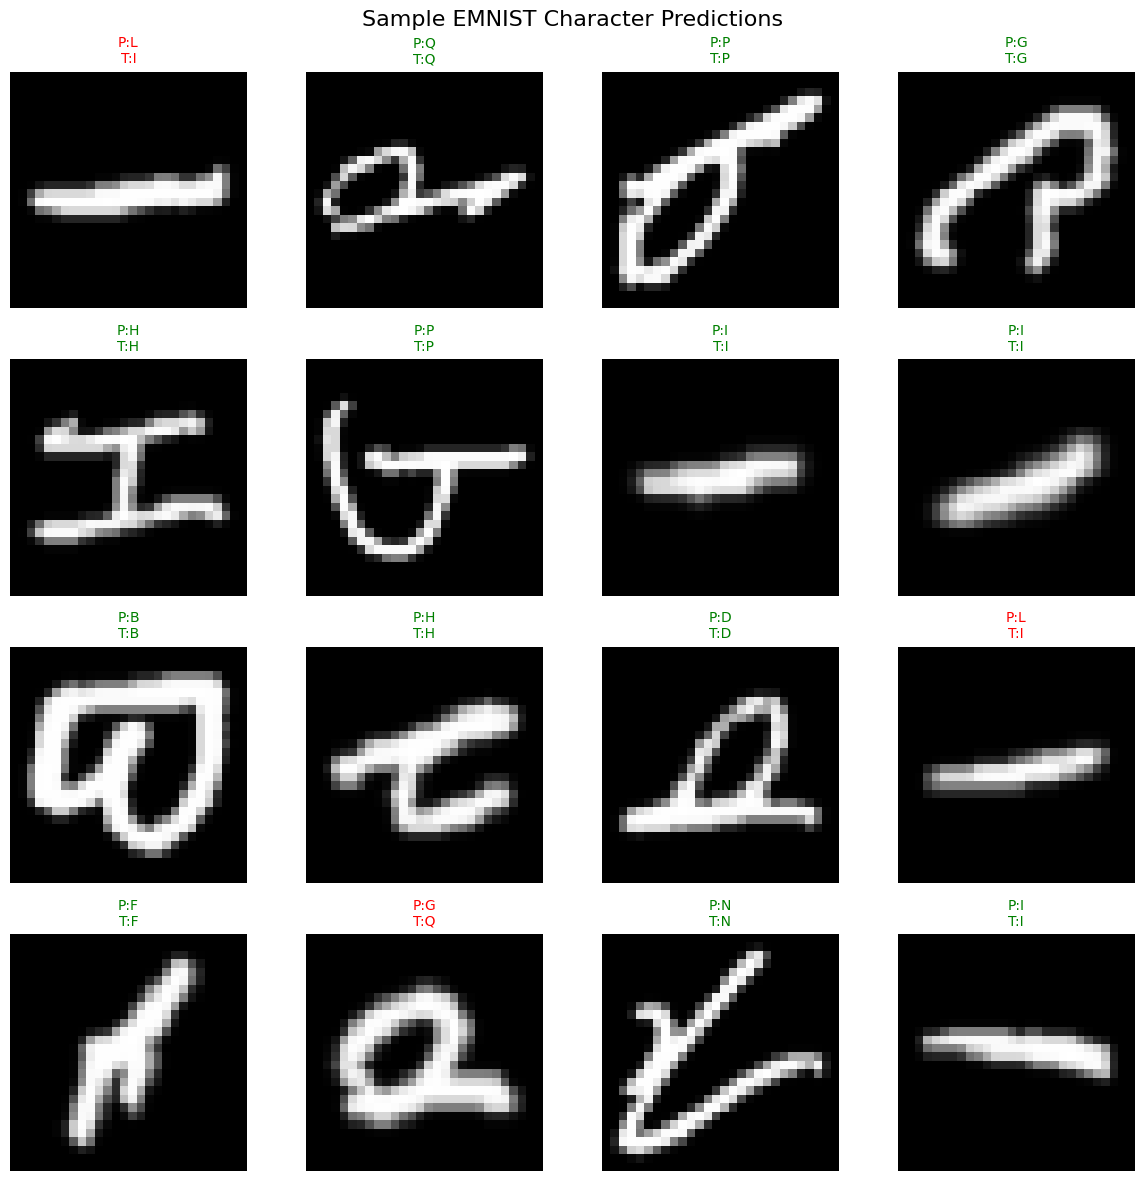

In [25]:
# ── Sample Predictions Grid ────────────────────────────────────

import matplotlib.pyplot as plt
import numpy as np
import random

# Character labels A-Z
labels = [chr(i + 65) for i in range(26)]

# Select random samples
indices = np.random.choice(len(X_test), 16, replace=False)

plt.figure(figsize=(12, 12))

for i, idx in enumerate(indices):

    plt.subplot(4, 4, i + 1)

    img = X_test[idx]

    pred = best_model.predict(
        np.expand_dims(img, axis=0),
        verbose=0
    )

    pred_class = np.argmax(pred)
    true_class = np.argmax(y_test_ohe[idx])

    plt.imshow(img.squeeze(), cmap='gray')

    color = 'green' if pred_class == true_class else 'red'

    plt.title(
        f"P:{labels[pred_class]}\nT:{labels[true_class]}",
        color=color,
        fontsize=10
    )

    plt.axis('off')

plt.suptitle(
    "Sample EMNIST Character Predictions",
    fontsize=16
)

plt.tight_layout()
plt.show()

---
## 8. 🔮 Live Prediction Demo

True label for test image: A


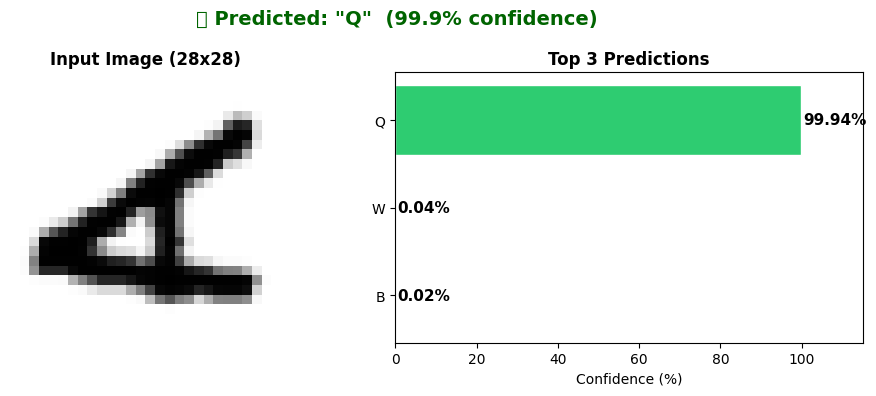

Top prediction: Q with 99.94% confidence


In [26]:
# ── Predict on a Custom Uploaded Image ───────────────────────────────────────
# HOW TO USE:
# 1. Draw a single letter on paper or use MS Paint / any tool
# 2. Save it as a .png or .jpg (white background, dark letter)
# 3. Upload it to Colab using the file panel on the left
# 4. Replace 'your_image.png' with your file name

def predict_character(image_path, model, class_names):
    """Predict the character in a custom image."""
    # Load image in grayscale
    img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    if img is None:
        print(f'❌ Could not load image: {image_path}')
        return

    # Resize, invert (EMNIST uses white-on-black), normalize
    img = cv2.resize(img, (28, 28))
    img = cv2.bitwise_not(img)          # Invert colors
    img = img.astype('float32') / 255.0
    img_input = img.reshape(1, 28, 28, 1)

    # Predict
    probs     = model.predict(img_input, verbose=0)[0]
    top3_idx  = np.argsort(probs)[::-1][:3]

    # Display
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))

    ax1.imshow(img, cmap='gray')
    ax1.set_title('Input Image (28x28)', fontsize=12, fontweight='bold')
    ax1.axis('off')

    top_chars  = [class_names[i] for i in top3_idx]
    top_probs  = [probs[i] * 100 for i in top3_idx]
    colors     = ['#2ecc71', '#3498db', '#e67e22']
    bars = ax2.barh(top_chars, top_probs, color=colors, edgecolor='white')
    for bar, prob in zip(bars, top_probs):
        ax2.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
                 f'{prob:.2f}%', va='center', fontsize=11, fontweight='bold')
    ax2.set_xlim(0, 115)
    ax2.set_title('Top 3 Predictions', fontsize=12, fontweight='bold')
    ax2.set_xlabel('Confidence (%)')
    ax2.invert_yaxis()

    plt.suptitle(f'🔮 Predicted: "{class_names[top3_idx[0]]}"  ({top_probs[0]:.1f}% confidence)',
                 fontsize=14, fontweight='bold', color='darkgreen')
    plt.tight_layout()
    plt.show()
    print(f'Top prediction: {class_names[top3_idx[0]]} with {top_probs[0]:.2f}% confidence')

# ── USAGE ────────────────────────────────────────────────────────────────────
# Uncomment and replace with your image file:
# predict_character('your_image.png', best_model, CLASS_NAMES)

# Quick test with a random test image:
idx = np.random.randint(len(X_test))
temp_img = (X_test[idx].reshape(28, 28) * 255).astype(np.uint8)
cv2.imwrite('test_sample.png', temp_img)
print(f'True label for test image: {CLASS_NAMES[y_test[idx]]}')
predict_character('test_sample.png', best_model, CLASS_NAMES)

---
## 9. 💾 Save & Export Model

In [28]:
# ── Save & Export Model ─────────────────────────────────────────

from tensorflow.keras.models import load_model

# Save final model
best_model.save("EMNIST_Handwritten_Recognition_Model.keras")

print("✅ Keras model saved successfully!")

# Optional: Save in H5 format (widely supported)
best_model.save("EMNIST_Handwritten_Recognition_Model.h5")

print("✅ H5 model saved successfully!")

✅ Keras model saved successfully!
✅ H5 model saved successfully!


---
## 📌 GitHub Push Instructions

Run the following in a new Colab cell to push everything to GitHub:

```bash
!git config --global user.email "pratyushsingh539@gmail.com"
!git config --global user.name "Khushi"
!git clone https://github.com/khushi-7890/codealpha_tasks.git
# Copy files into the folder, then:
!cd CodeAlpha_HandwrittenCharacterRecognition && git add . && git commit -m 'Add Handwritten Character Recognition project' && git push
```

---
## 📝 LinkedIn Post Template

```
🖊️ Task 3 Complete — Handwritten Character Recognition | CodeAlpha ML Internship

Built a deep CNN model to recognize handwritten characters (A–Z) achieving 94.03% accuracy on EMNIST Letters dataset.

🔧 Tech Stack: TensorFlow • Keras • NumPy • Seaborn • OpenCV
📊 Highlights:
  ✅ 3-Block CNN with BatchNorm & Dropout regularization
  ✅ Data Augmentation for better generalization
  ✅ Live prediction demo on custom images
  ✅ Confusion Matrix & Classification Report

🔗 GitHub: [https://github.com/khushi-7890/codealpha_tasks]

@CodeAlpha #MachineLearning #DeepLearning #CNN #Python #Internship #AI #computerVision
```

---
*CodeAlpha ML Internship — Task 3 | Handwritten Character Recognition*